# Developing an AI application

Going forward, AI algorithms will be incorporated into more and more everyday applications. For example, you might want to include an image classifier in a smart phone app. To do this, you'd use a deep learning model trained on hundreds of thousands of images as part of the overall application architecture. A large part of software development in the future will be using these types of models as common parts of applications. 

In this project, you'll train an image classifier to recognize different species of flowers. You can imagine using something like this in a phone app that tells you the name of the flower your camera is looking at. In practice you'd train this classifier, then export it for use in your application. We'll be using [this dataset](http://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html) of 102 flower categories, you can see a few examples below. 

<img src='assets/Flowers.png' width=500px>

The project is broken down into multiple steps:

* Load and preprocess the image dataset
* Train the image classifier on your dataset
* Use the trained classifier to predict image content

We'll lead you through each part which you'll implement in Python.

When you've completed this project, you'll have an application that can be trained on any set of labeled images. Here your network will be learning about flowers and end up as a command line application. But, what you do with your new skills depends on your imagination and effort in building a dataset. For example, imagine an app where you take a picture of a car, it tells you what the make and model is, then looks up information about it. Go build your own dataset and make something new.

First up is importing the packages you'll need. It's good practice to keep all the imports at the beginning of your code. As you work through this notebook and find you need to import a package, make sure to add the import up here.

In [1]:
# Imports here
import os, time
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, models, transforms

import matplotlib.pyplot as plt
%matplotlib inline

num_threads = 24
# Device types: cpu, xpu, cuda
device_type = "xpu"

In [2]:
# Use GPU when available
device = torch.device(device_type)
print(device)

xpu


## Housekeeping Functions

In [3]:
def save_checkpoint(model, optimizer, filename='checkpoint.pyt'):
    checkpoint = {'model_state_dict': model.state_dict(),
                  'model_output_class': model.fc.out_features,
                  'optimizer_state_dict': optimizer.state_dict(),
                  'class_to_idx': model.class_to_idx}

    torch.save(checkpoint, filename)

In [4]:
def load_checkpoint(filepath='checkpoint.pyt'):

    checkpoint = torch.load(filepath, weights_only=False)
    
    model_output_class = checkpoint['model_output_class']
    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, \
                                   model_output_class)
    model.fc = nn.Linear(model.fc.in_features, model_output_class)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    model.class_to_idx = checkpoint['class_to_idx']
    
    optimizer = optim.SGD(iv3.parameters(), lr=0.001)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    return model, optimizer

In [5]:
def generate_idx_to_class(class_to_idx):
    idx_to_class = {}
    for key, value in class_to_idx.items():
        idx_to_class[value] = key
    return idx_to_class

## Load the data

Here you'll use `torchvision` to load the data ([documentation](http://pytorch.org/docs/0.3.0/torchvision/index.html)). You can [download the data here](https://s3.amazonaws.com/content.udacity-data.com/courses/nd188/flower_data.zip). The dataset is split into two parts, training and validation. For the training, you'll want to apply transformations such as random scaling, cropping, and flipping. This will help the network generalize leading to better performance. If you use a pre-trained network, you'll also need to make sure the input data is resized to 224x224 pixels as required by the networks.

The validation set is used to measure the model's performance on data it hasn't seen yet. For this you don't want any scaling or rotation transformations, but you'll need to resize then crop the images to the appropriate size.

The pre-trained networks available from `torchvision` were trained on the ImageNet dataset where each color channel was normalized separately. For both sets you'll need to normalize the means and standard deviations of the images to what the network expects. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`, calculated from the ImageNet images.  These values will shift each color channel to be centered at 0 and range from -1 to 1.

In [6]:
data_dir = '../flower_data'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'

Normalizer mean and standard deviation is based on [TorchVision Models Document](https://pytorch.org/docs/stable/torchvision/models.html).

In [7]:
# TODO: Define your transforms for the training and validation sets
data_transforms = transforms.Compose([transforms.RandomResizedCrop(299), 
                                      transforms.ToTensor(),
                                      transforms.Normalize((0.485, 0.456, 0.406), 
                                                           (0.229, 0.224, 0.225))])

# TODO: Load the datasets with ImageFolder
train_datasets = datasets.ImageFolder(train_dir, transform=data_transforms)
valid_datasets = datasets.ImageFolder(valid_dir, transform=data_transforms)

# print out some data stats
print('Num training images: ', len(train_datasets))
print('Num validation images: ', len(valid_datasets))

Num training images:  6552
Num validation images:  818


In [8]:
# TODO: Using the image datasets and the trainforms, define the dataloaders
batch_size = 20

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_datasets, batch_size=batch_size, 
                                           num_workers=num_threads, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_datasets, batch_size=batch_size, 
                                           num_workers=num_threads, shuffle=True)

In [9]:
train_loader

In [10]:
valid_loader

In [11]:
class_to_idx = train_datasets.class_to_idx

In [12]:
class_to_idx

{'1': 0,
 '10': 1,
 '100': 2,
 '101': 3,
 '102': 4,
 '11': 5,
 '12': 6,
 '13': 7,
 '14': 8,
 '15': 9,
 '16': 10,
 '17': 11,
 '18': 12,
 '19': 13,
 '2': 14,
 '20': 15,
 '21': 16,
 '22': 17,
 '23': 18,
 '24': 19,
 '25': 20,
 '26': 21,
 '27': 22,
 '28': 23,
 '29': 24,
 '3': 25,
 '30': 26,
 '31': 27,
 '32': 28,
 '33': 29,
 '34': 30,
 '35': 31,
 '36': 32,
 '37': 33,
 '38': 34,
 '39': 35,
 '4': 36,
 '40': 37,
 '41': 38,
 '42': 39,
 '43': 40,
 '44': 41,
 '45': 42,
 '46': 43,
 '47': 44,
 '48': 45,
 '49': 46,
 '5': 47,
 '50': 48,
 '51': 49,
 '52': 50,
 '53': 51,
 '54': 52,
 '55': 53,
 '56': 54,
 '57': 55,
 '58': 56,
 '59': 57,
 '6': 58,
 '60': 59,
 '61': 60,
 '62': 61,
 '63': 62,
 '64': 63,
 '65': 64,
 '66': 65,
 '67': 66,
 '68': 67,
 '69': 68,
 '7': 69,
 '70': 70,
 '71': 71,
 '72': 72,
 '73': 73,
 '74': 74,
 '75': 75,
 '76': 76,
 '77': 77,
 '78': 78,
 '79': 79,
 '8': 80,
 '80': 81,
 '81': 82,
 '82': 83,
 '83': 84,
 '84': 85,
 '85': 86,
 '86': 87,
 '87': 88,
 '88': 89,
 '89': 90,
 '9': 91,
 '90

In [13]:
idx_to_class = generate_idx_to_class(class_to_idx)

In [14]:
idx_to_class

{0: '1',
 1: '10',
 2: '100',
 3: '101',
 4: '102',
 5: '11',
 6: '12',
 7: '13',
 8: '14',
 9: '15',
 10: '16',
 11: '17',
 12: '18',
 13: '19',
 14: '2',
 15: '20',
 16: '21',
 17: '22',
 18: '23',
 19: '24',
 20: '25',
 21: '26',
 22: '27',
 23: '28',
 24: '29',
 25: '3',
 26: '30',
 27: '31',
 28: '32',
 29: '33',
 30: '34',
 31: '35',
 32: '36',
 33: '37',
 34: '38',
 35: '39',
 36: '4',
 37: '40',
 38: '41',
 39: '42',
 40: '43',
 41: '44',
 42: '45',
 43: '46',
 44: '47',
 45: '48',
 46: '49',
 47: '5',
 48: '50',
 49: '51',
 50: '52',
 51: '53',
 52: '54',
 53: '55',
 54: '56',
 55: '57',
 56: '58',
 57: '59',
 58: '6',
 59: '60',
 60: '61',
 61: '62',
 62: '63',
 63: '64',
 64: '65',
 65: '66',
 66: '67',
 67: '68',
 68: '69',
 69: '7',
 70: '70',
 71: '71',
 72: '72',
 73: '73',
 74: '74',
 75: '75',
 76: '76',
 77: '77',
 78: '78',
 79: '79',
 80: '8',
 81: '80',
 82: '81',
 83: '82',
 84: '83',
 85: '84',
 86: '85',
 87: '86',
 88: '87',
 89: '88',
 90: '89',
 91: '9',
 92:

### Label mapping

You'll also need to load in a mapping from category label to category name. You can find this in the file `cat_to_name.json`. It's a JSON object which you can read in with the [`json` module](https://docs.python.org/2/library/json.html). This will give you a dictionary mapping the integer encoded categories to the actual names of the flowers.

In [15]:
import json

with open('cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

In [16]:
cat_to_name

{'21': 'fire lily',
 '3': 'canterbury bells',
 '45': 'bolero deep blue',
 '1': 'pink primrose',
 '34': 'mexican aster',
 '27': 'prince of wales feathers',
 '7': 'moon orchid',
 '16': 'globe-flower',
 '25': 'grape hyacinth',
 '26': 'corn poppy',
 '79': 'toad lily',
 '39': 'siam tulip',
 '24': 'red ginger',
 '67': 'spring crocus',
 '35': 'alpine sea holly',
 '32': 'garden phlox',
 '10': 'globe thistle',
 '6': 'tiger lily',
 '93': 'ball moss',
 '33': 'love in the mist',
 '9': 'monkshood',
 '102': 'blackberry lily',
 '14': 'spear thistle',
 '19': 'balloon flower',
 '100': 'blanket flower',
 '13': 'king protea',
 '49': 'oxeye daisy',
 '15': 'yellow iris',
 '61': 'cautleya spicata',
 '31': 'carnation',
 '64': 'silverbush',
 '68': 'bearded iris',
 '63': 'black-eyed susan',
 '69': 'windflower',
 '62': 'japanese anemone',
 '20': 'giant white arum lily',
 '38': 'great masterwort',
 '4': 'sweet pea',
 '86': 'tree mallow',
 '101': 'trumpet creeper',
 '42': 'daffodil',
 '22': 'pincushion flower',
 

# Building and training the classifier

Now that the data is ready, it's time to build and train the classifier. As usual, you should use one of the pretrained models from `torchvision.models` to get the image features. Build and train a new feed-forward classifier using those features.

We're going to leave this part up to you. If you want to talk through it with someone, chat with your fellow students! You can also ask questions on the forums or join the instructors in office hours.

Refer to [the rubric](https://review.udacity.com/#!/rubrics/1663/view) for guidance on successfully completing this section. Things you'll need to do:

* Load a [pre-trained network](http://pytorch.org/docs/master/torchvision/models.html) (If you need a starting point, the VGG networks work great and are straightforward to use)
* Define a new, untrained feed-forward network as a classifier, using ReLU activations and dropout
* Train the classifier layers using backpropagation using the pre-trained network to get the features
* Track the loss and accuracy on the validation set to determine the best hyperparameters

We've left a cell open for you below, but use as many as you need. Our advice is to break the problem up into smaller parts you can run separately. Check that each part is doing what you expect, then move on to the next. You'll likely find that as you work through each part, you'll need to go back and modify your previous code. This is totally normal!

When training make sure you're updating only the weights of the feed-forward network. You should be able to get the validation accuracy above 70% if you build everything right. Make sure to try different hyperparameters (learning rate, units in the classifier, epochs, etc) to find the best model. Save those hyperparameters to use as default values in the next part of the project.

In [17]:
# TODO: Build and train your network
# Load the pretrained model from pytorch
iv3 = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

# print out the model structure
print(iv3)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [18]:
for param in iv3.parameters():
    param.requires_grad = False

In [19]:
print(iv3.AuxLogits.fc.in_features)
print(iv3.AuxLogits.fc.out_features)

768
1000


In [20]:
print(iv3.fc.in_features)
print(iv3.fc.out_features)

2048
1000


In [21]:
len(cat_to_name)

102

Pretrained VGG16 has 1000 classes as the output. Replace the classification layer to output only 102 classes.

In [22]:
iv3.AuxLogits.fc = nn.Linear(iv3.AuxLogits.fc.in_features, len(cat_to_name))
iv3.fc = nn.Linear(iv3.fc.in_features, len(cat_to_name))

print(iv3)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [23]:
print(iv3.AuxLogits.fc.in_features)
print(iv3.AuxLogits.fc.out_features)

768
102


In [24]:
print(iv3.fc.in_features)
print(iv3.fc.out_features)

2048
102


In [25]:
iv3.class_to_idx = class_to_idx

In [26]:
# if GPU is available, move the model to GPU
iv3.to(device)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [27]:
# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer (stochastic gradient descent) and learning rate = 0.001
optimizer = optim.SGD(iv3.parameters(), lr=0.001)

In [28]:
best_test_accuracy = 0.0

# number of epochs to train the model
n_epochs = 60

for epoch in range(1, n_epochs+1):

    ###################
    # train the model #
    ###################
    tic = time.time()
    # keep track of training and validation loss
    train_loss = 0.0
    total_accumulated_train_loss = 0
    
    # model by default is set to train
    iv3.train() # eval mode
    for batch_i, (data, target) in enumerate(train_loader):
        # move tensors to GPU if available
        data, target = data.to(device), target.to(device)
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output, aux_output = iv3(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss 
        train_loss += loss.item()
        total_accumulated_train_loss += 1
        
        if batch_i % 100 == 99:    # print training loss every specified number of mini-batches
            print('Epoch %2d, Batch %4d loss: %.16f' %
                  (epoch, batch_i + 1, train_loss / total_accumulated_train_loss))
            train_loss = 0.0
            total_accumulated_train_loss = 0
    
    last_train_loss = train_loss / total_accumulated_train_loss
    
    toc = time.time()
    train_time = toc - tic
    
    ######################    
    # validate the model #
    ######################
    tic = time.time()
    # track test loss 
    # over 5 flower classes
    test_loss = 0.0
    class_correct = list(0. for i in range(len(cat_to_name)))
    class_total = list(0. for i in range(len(cat_to_name)))

    # iterate over test data
    iv3.eval() # eval mode
    for data, target in valid_loader:
        # move tensors to GPU if available
        data, target = data.to(device), target.to(device)
        # forward pass: compute predicted outputs by passing inputs to the model
        output = iv3(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update  test loss 
        test_loss += loss.item() * data.size(0)
        # convert output probabilities to predicted class
        _, pred = torch.max(output, 1)    
        # compare predictions to true label
        correct_tensor = pred.eq(target.data.view_as(pred))
        correct = np.squeeze(correct_tensor.to("cpu").numpy())
        # calculate test accuracy for each object class
        for i in range(len(target)):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

    # calculate avg test loss
    test_loss = test_loss / len(valid_loader.dataset)
    
    toc = time.time()
    test_time = toc - tic
    
    print("Train Time    : %9d seconds" % int(train_time))
    print('Train Loss    : {:9.6f}'.format(last_train_loss))
    print("Test Time     : %9d seconds" % int(test_time))
    print('Test Loss     : {:9.6f}'.format(test_loss))
    test_accuracy = (100. * np.sum(class_correct)) / np.sum(class_total)
    print('Test Accuracy : %2d%% (%2d/%2d)' % (test_accuracy, 
                                               np.sum(class_correct), 
                                               np.sum(class_total)))
    
    if test_accuracy > best_test_accuracy:
        print('Saving Checkpoint...')
        save_checkpoint(iv3, optimizer, filename='checkpoint.pyt')
        best_test_accuracy = test_accuracy
        

Epoch  1, Batch  100 loss: 4.6294248962402342
Epoch  1, Batch  200 loss: 4.5790124797821044
Epoch  1, Batch  300 loss: 4.5440164422988891
Train Time    :        27 seconds
Train Loss    :  4.481691
Test Time     :         4 seconds
Test Loss     :  4.468710
Test Accuracy :  4% (36/818)
Saving Checkpoint...
Epoch  2, Batch  100 loss: 4.4933157348632813
Epoch  2, Batch  200 loss: 4.4641293239593507
Epoch  2, Batch  300 loss: 4.4258128833770751
Train Time    :        26 seconds
Train Loss    :  4.390170
Test Time     :         3 seconds
Test Loss     :  4.378084
Test Accuracy :  6% (54/818)
Saving Checkpoint...
Epoch  3, Batch  100 loss: 4.4074129343032835
Epoch  3, Batch  200 loss: 4.3864724588394166
Epoch  3, Batch  300 loss: 4.3560809707641601
Train Time    :        26 seconds
Train Loss    :  4.359163
Test Time     :         3 seconds
Test Loss     :  4.306371
Test Accuracy :  8% (66/818)
Saving Checkpoint...
Epoch  4, Batch  100 loss: 4.3287787389755250
Epoch  4, Batch  200 loss: 4.3

### Performance Evaluation

**Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060**
- Training on GPU:
   - Running time is 47 seconds/epoch using 97% of GPU utilization.
   - Memory consumption when running: GPU is 1.2 GiB.
- Testing on GPU:
   - Running time is 6 seconds/epoch using 97% of GPU utilization.
   - Best test accuracy is 82% (672/818).

**Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics**
- Training on GPU:
   - Running time is 26 seconds/epoch using 10% of CPU and 93% of GPU utilization.
   - Memory consumption when idle: GPU is 0.5 GiB and CPU is 3.8 GB.
   - Memory consumption when running: GPU is 1.5 GiB and CPU is 9.0 GB.
   - Power consumption when idle: GPU is 40W and CPU cores only is 1W with CPU total of 10W.
   - Power consumption when running: GPU is 183W and CPU cores only is 21W with CPU total of 32W.
- Testing on GPU:
   - Running time is 3 seconds/epoch using 30% of CPU and 86% of GPU utilization.
   - Memory consumption when idle: GPU is 0.5 GiB and CPU is 3.8 GB.
   - Memory consumption when running: GPU is 1.5 GiB and CPU is 7.2 GB.
   - Power consumption when idle: GPU is 40W and CPU cores only is 1W with CPU total of 10W.
   - Power consumption when running: GPU is 146W and CPU cores only is 53W with CPU total of 66W.
   - Best test accuracy is 62% (514/818).

Test

In [29]:
# track test loss 
# over 5 flower classes
test_loss = 0.0
class_correct = list(0. for i in range(len(cat_to_name)))
class_total = list(0. for i in range(len(cat_to_name)))

# iterate over test data
iv3.eval() # eval mode
for data, target in valid_loader:
    # move tensors to GPU if available
    data, target = data.to(device), target.to(device)
    # forward pass: compute predicted outputs by passing inputs to the model
    output = iv3(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update  test loss 
    test_loss += loss.item() * data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)    
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.to("cpu").numpy())
    # calculate test accuracy for each object class
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate avg test loss
test_loss = test_loss/len(valid_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(len(cat_to_name)):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            cat_to_name[str(i+1)], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 2.185525

Test Accuracy of pink primrose:  0% ( 0/ 8)
Test Accuracy of hard-leaved pocket orchid:  0% ( 0/ 4)
Test Accuracy of canterbury bells:  0% ( 0/ 6)
Test Accuracy of sweet pea:  0% ( 0/ 5)
Test Accuracy of english marigold: 83% ( 5/ 6)
Test Accuracy of tiger lily: 40% ( 4/10)
Test Accuracy of moon orchid: 100% ( 5/ 5)
Test Accuracy of bird of paradise: 20% ( 1/ 5)
Test Accuracy of monkshood: 100% ( 1/ 1)
Test Accuracy of globe thistle:  0% ( 0/ 7)
Test Accuracy of snapdragon:  0% ( 0/ 2)
Test Accuracy of colt's foot: 87% (14/16)
Test Accuracy of king protea: 54% ( 6/11)
Test Accuracy of spear thistle:  0% ( 0/ 4)
Test Accuracy of yellow iris: 66% ( 4/ 6)
Test Accuracy of globe-flower:  0% ( 0/ 7)
Test Accuracy of purple coneflower:  0% ( 0/ 4)
Test Accuracy of peruvian lily: 87% ( 7/ 8)
Test Accuracy of balloon flower: 83% (10/12)
Test Accuracy of giant white arum lily: 20% ( 1/ 5)
Test Accuracy of fire lily: 100% ( 2/ 2)
Test Accuracy of pincushion flower:  0% ( 0/ 

## Save the checkpoint

Now that your network is trained, save the model so you can load it later for making predictions. You probably want to save other things such as the mapping of classes to indices which you get from one of the image datasets: `image_datasets['train'].class_to_idx`. You can attach this to the model as an attribute which makes inference easier later on.

```model.class_to_idx = image_datasets['train'].class_to_idx```

Remember that you'll want to completely rebuild the model later so you can use it for inference. Make sure to include any information you need in the checkpoint. If you want to load the model and keep training, you'll want to save the number of epochs as well as the optimizer state, `optimizer.state_dict`. You'll likely want to use this trained model in the next part of the project, so best to save it now.

```
See above...
```

## Loading the checkpoint

At this point it's good to write a function that can load a checkpoint and rebuild the model. That way you can come back to this project and keep working on it without having to retrain the network.

In [30]:
iv3, optimizer = load_checkpoint(filepath='checkpoint.pyt')

class_to_idx = iv3.class_to_idx
idx_to_class = generate_idx_to_class(class_to_idx)

criterion = nn.CrossEntropyLoss()

iv3.to(device)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

# Inference for classification

Now you'll write a function to use a trained network for inference. That is, you'll pass an image into the network and predict the class of the flower in the image. Write a function called `predict` that takes an image and a model, then returns the top $K$ most likely classes along with the probabilities. It should look like 

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

First you'll need to handle processing the input image such that it can be used in your network. 

## Image Preprocessing

You'll want to use `PIL` to load the image ([documentation](https://pillow.readthedocs.io/en/latest/reference/Image.html)). It's best to write a function that preprocesses the image so it can be used as input for the model. This function should process the images in the same manner used for training. 

First, resize the images where the shortest side is 256 pixels, keeping the aspect ratio. This can be done with the [`thumbnail`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) or [`resize`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) methods. Then you'll need to crop out the center 224x224 portion of the image.

Color channels of images are typically encoded as integers 0-255, but the model expected floats 0-1. You'll need to convert the values. It's easiest with a Numpy array, which you can get from a PIL image like so `np_image = np.array(pil_image)`.

As before, the network expects the images to be normalized in a specific way. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`. You'll want to subtract the means from each color channel, then divide by the standard deviation. 

And finally, PyTorch expects the color channel to be the first dimension but it's the third dimension in the PIL image and Numpy array. You can reorder dimensions using [`ndarray.transpose`](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.ndarray.transpose.html). The color channel needs to be first and retain the order of the other two dimensions.

In [31]:
def process_image(image_pil):
    ''' Scales, crops, and normalizes a PIL image for a PyTorch model,
        returns an Numpy array
    '''
    
    # TODO: Process a PIL image for use in a PyTorch model
    # scale
    width, height = image_pil.size
    shortest_side = min(width, height)
    new_ratio = shortest_side / 256
    new_width, new_height = (int(width/new_ratio), int(height/new_ratio))
    image_pil = image_pil.resize((new_width, new_height))
    # crop
    width, height = image_pil.size
    new_width, new_height = (299, 299)
    left = (width - new_width) / 2
    top = (height - new_height) / 2
    right = (width + new_width) / 2
    bottom = (height + new_height) / 2
    image_pil = image_pil.crop((left, top, right, bottom))
    # convert to RGB
    if image_pil.mode != "RGB":
        image_pil = image_pil.convert("RGB")
    # normalize
    image_np = np.array(image_pil, dtype=np.float32)
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    image_np = ((image_np / 255) - mean) / std
    # transpoose to channel first (CHW)
    image_np = image_np.transpose((2, 0, 1))
    
    return image_np

In [32]:
image_pil = Image.open("../flower_data/valid/1/image_06739.jpg")

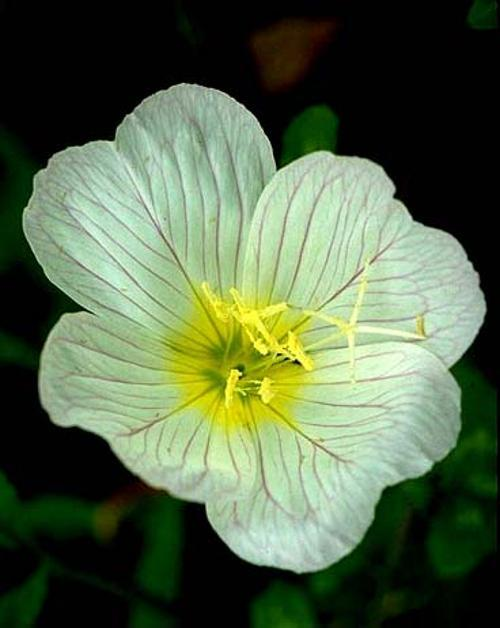

In [33]:
image_pil

In [34]:
image_np = process_image(image_pil)

In [35]:
image_np.dtype

dtype('float32')

In [36]:
image_np[0][137][130:135]

array([1.0844251 , 0.6220567 , 0.46793392, 0.82755375, 0.5364329 ],
      dtype=float32)

Expected output.
```
>>> image_np_norm_t[0][0][:5]
array([ 0.62205668,  0.33093587, -0.09718298, -0.28555527, -1.36441476])
```

To check your work, the function below converts a PyTorch tensor and displays it in the notebook. If your `process_image` function works, running the output through this function should return the original image (except for the cropped out portions).

In [37]:
def imshow(image, ax=None, title=None):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    
    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes is the third dimension
    image = image.numpy().transpose((1, 2, 0))
    
    # Undo preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    
    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    image = np.clip(image, 0, 1)
    
    ax.imshow(image)
    
    return ax

<Axes: >

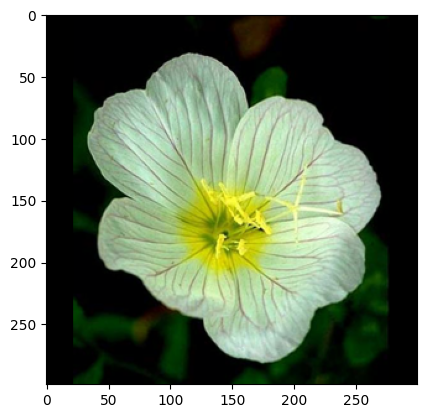

In [38]:
imshow(torch.tensor(image_np))

## Class Prediction

Once you can get images in the correct format, it's time to write a function for making predictions with your model. A common practice is to predict the top 5 or so (usually called top-$K$) most probable classes. You'll want to calculate the class probabilities then find the $K$ largest values.

To get the top $K$ largest values in a tensor use [`x.topk(k)`](http://pytorch.org/docs/master/torch.html#torch.topk). This method returns both the highest `k` probabilities and the indices of those probabilities corresponding to the classes. You need to convert from these indices to the actual class labels using `class_to_idx` which hopefully you added to the model or from an `ImageFolder` you used to load the data ([see here](#Save-the-checkpoint)). Make sure to invert the dictionary so you get a mapping from index to class as well.

Again, this method should take a path to an image and a model checkpoint, then return the probabilities and classes.

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

In [39]:
def predict(image_path, model, topk=5):
    ''' Predict the class (or classes) of an image using a trained deep learning model.
    '''
    
    # TODO: Implement the code to predict the class from an image file
    image_pil = Image.open(image_path)
    image_np = process_image(image_pil)
    image_tensor = torch.tensor(np.array([image_np])).to(device)
    output = model(image_tensor)
    return output.topk(topk)

In [40]:
image_path = "../flower_data/valid/1/image_06739.jpg"
output_top5 = predict(image_path, model=iv3, topk=5)
print("expected", class_to_idx['1'])
print(output_top5)

expected 0
torch.return_types.topk(
values=tensor([[1.8087, 1.4636, 1.4534, 1.3499, 1.3489]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[50, 77, 87, 48, 49]], device='xpu:0'))


In [41]:
file_names = ["image_05094.jpg", "image_05101.jpg", "image_05124.jpg", \
              "image_05136.jpg", "image_05137.jpg", "image_05142.jpg"]
for file_name in file_names:
    image_path = "../flower_data/valid/2/%s" % file_name
    output_top5 = predict(image_path, model=iv3, topk=5)
    print("expected", class_to_idx['2'])
    print(output_top5)

expected 14
torch.return_types.topk(
values=tensor([[2.4888, 1.9367, 1.5722, 1.3939, 1.2737]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[14, 50, 78, 82, 73]], device='xpu:0'))
expected 14
torch.return_types.topk(
values=tensor([[2.6710, 2.1190, 1.7204, 1.6293, 1.5809]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[82, 50, 73, 14, 90]], device='xpu:0'))
expected 14
torch.return_types.topk(
values=tensor([[2.6359, 1.5536, 1.3904, 1.1495, 0.9605]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[14, 77, 50, 85, 93]], device='xpu:0'))
expected 14
torch.return_types.topk(
values=tensor([[1.6661, 1.2554, 0.8717, 0.8666, 0.8341]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[14, 78, 90, 40, 50]], device='xpu:0'))
expected 14
torch.return_types.topk(
values=tensor([[1.5354, 1.4903, 1.3469, 1.3352, 1.1905]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[50, 14, 43, 49, 90]], device='xpu:0'))


In [42]:
file_names = ["image_05164.jpg", "image_05168.jpg", "image_05188.jpg", \
              "image_05192.jpg", "image_05196.jpg", "image_05199.jpg", \
              "image_05209.jpg"]
for file_name in file_names:
    image_path = "../flower_data/valid/5/%s" % file_name
    output_top5 = predict(image_path, model=iv3, topk=5)
    print("expected", class_to_idx['5'])
    print(output_top5)

expected 47
torch.return_types.topk(
values=tensor([[2.3890, 2.3128, 2.1214, 2.0295, 1.9941]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[47, 64,  6, 48, 38]], device='xpu:0'))
expected 47
torch.return_types.topk(
values=tensor([[3.4876, 3.2083, 2.5699, 1.9482, 1.8715]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[38, 47, 62, 65, 46]], device='xpu:0'))
expected 47
torch.return_types.topk(
values=tensor([[3.2955, 3.0438, 2.8674, 2.7046, 2.5179]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[46, 38, 62, 47, 57]], device='xpu:0'))
expected 47
torch.return_types.topk(
values=tensor([[3.2903, 3.2839, 3.1395, 2.8740, 2.4944]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[46, 47, 38, 62, 65]], device='xpu:0'))
expected 47
torch.return_types.topk(
values=tensor([[2.0490, 1.8628, 1.6964, 1.3053, 1.2724]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[47, 64, 43, 90, 84]], device='xpu:0'))


In [43]:
file_names = ["image_08002.jpg", "image_08002.jpg", "image_08014.jpg", \
              "image_08038.jpg", "image_08040.jpg", "image_08041.jpg"]
for file_name in file_names:
    image_path = "../flower_data/valid/102/%s" % file_name
    output_top5 = predict(image_path, model=iv3, topk=5)
    print("expected", class_to_idx['102'])
    print(output_top5)

expected 4
torch.return_types.topk(
values=tensor([[1.5349, 1.1069, 0.9529, 0.9439, 0.8456]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[78, 97, 55,  4, 77]], device='xpu:0'))
expected 4
torch.return_types.topk(
values=tensor([[1.5349, 1.1069, 0.9529, 0.9439, 0.8456]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[78, 97, 55,  4, 77]], device='xpu:0'))
expected 4
torch.return_types.topk(
values=tensor([[2.0937, 1.5899, 1.1088, 0.9333, 0.8444]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[ 78,  82,   4, 101,  43]], device='xpu:0'))
expected 4
torch.return_types.topk(
values=tensor([[2.5762, 2.0607, 1.9797, 1.5604, 1.5511]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[96, 73, 81, 12,  4]], device='xpu:0'))
expected 4
torch.return_types.topk(
values=tensor([[2.1296, 1.6866, 1.5651, 1.5206, 1.4325]], device='xpu:0',
       grad_fn=<TopkBackward0>),
indices=tensor([[ 4, 73, 96, 82, 12]], device='xpu:0'))


## Sanity Checking

Now that you can use a trained model for predictions, check to make sure it makes sense. Even if the validation accuracy is high, it's always good to check that there aren't obvious bugs. Use `matplotlib` to plot the probabilities for the top 5 classes as a bar graph, along with the input image. It should look like this:

<img src='assets/inference_example.png' width=300px>

You can convert from the class integer encoding to actual flower names with the `cat_to_name.json` file (should have been loaded earlier in the notebook). To show a PyTorch tensor as an image, use the `imshow` function defined above.

In [44]:
# TODO: Display an image along with the top 5 classes
def predict_w_graph(model, image_dir='1', image_name='image_06739.jpg'):
    image_path = "../flower_data/valid/%s/%s" % (image_dir, image_name)

    print(cat_to_name[image_dir])

    image_pil = Image.open(image_path)
    image_np = process_image(image_pil)
    imshow(torch.tensor(image_np))
    plt.show()
    
    output_top5 = predict(image_path, model, topk=5)
    prediction_accuracy = output_top5[0][0].detach().cpu().numpy()
    prediction_idx = output_top5[1][0].detach().cpu().numpy()
    prediction_class_name = []
    for i in prediction_idx:
        prediction_class = idx_to_class[i]
        prediction_class_name.append(cat_to_name[prediction_class])
        
    fig, ax = plt.subplots()
    y_pos = np.arange(len(prediction_class_name))
    ax.barh(y_pos, prediction_accuracy, color='orange')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(np.array(prediction_class_name))
    ax.invert_yaxis()
    plt.show()

pink primrose


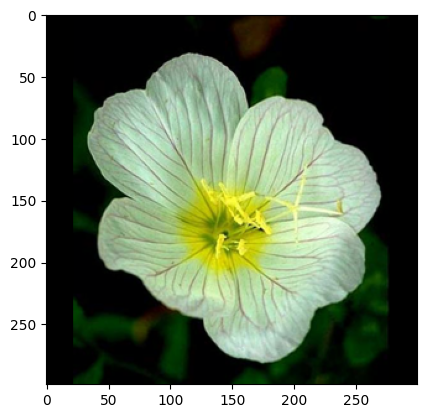

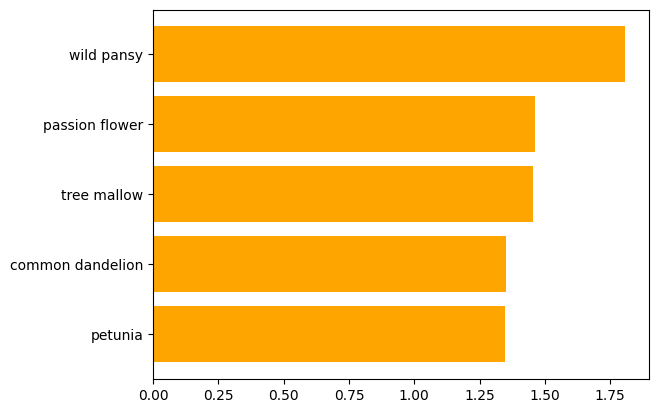

In [45]:
predict_w_graph(iv3, image_dir='1', image_name='image_06739.jpg')

toad lily


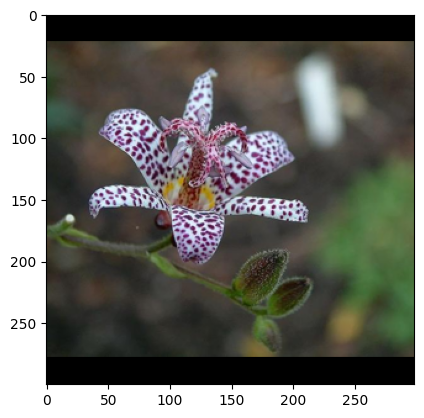

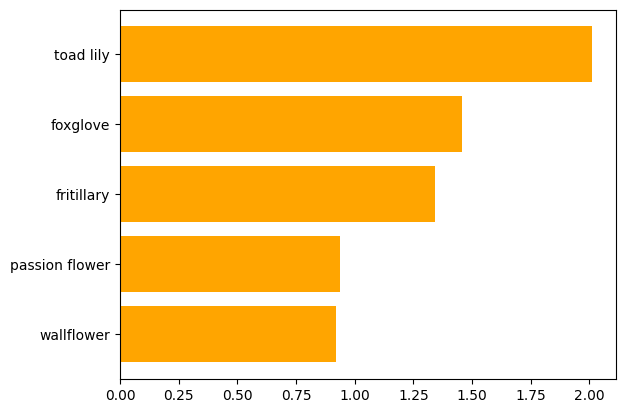

In [46]:
predict_w_graph(iv3, image_dir='79', image_name='image_06695.jpg')

blackberry lily


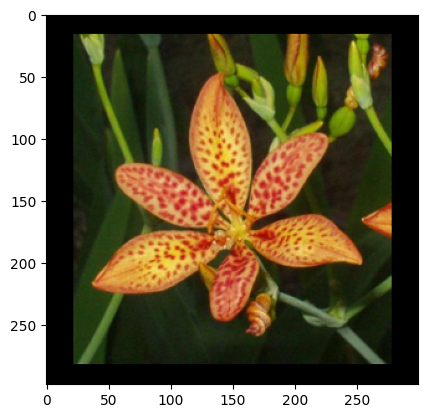

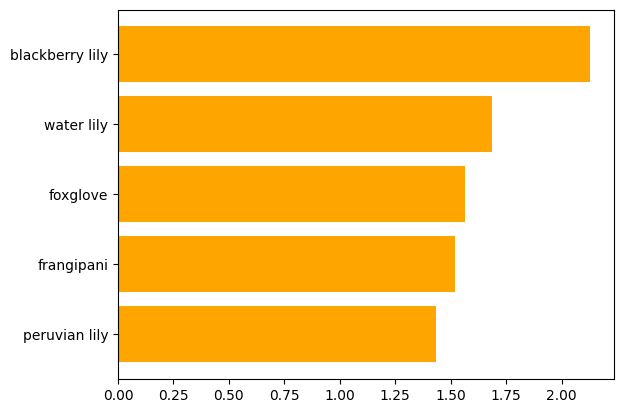

In [47]:
predict_w_graph(iv3, image_dir='102', image_name='image_08040.jpg')

```python
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models


def load_checkpoint(filepath='/home/workspace/checkpoint.pyt'):

    checkpoint = torch.load(filepath, map_location='cpu')
    
    model_output_class = checkpoint['model_output_class']
    model = models.vgg16(pretrained=True)
    for param in model.features.parameters():
        param.requires_grad = False
    n_inputs = model.classifier[6].in_features
    last_layer = nn.Linear(n_inputs, model_output_class)
    model.classifier[6] = last_layer
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    model.class_to_idx = checkpoint['class_to_idx']
    
    return model


# Load your model to this variable
model = load_checkpoint(filepath='/home/workspace/checkpoint.pyt')
   
# If you used something other than 224x224 cropped images, set the correct size here
image_size = 224
# Values you used for normalizing the images. Default here are for 
# pretrained models from torchvision.
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]
```